# incindent flux プロット

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from os.path import join
from scipy.interpolate import interp1d
import numpy as np
from scipy.signal import savgol_filter

plt.rcParams["font.weight"] = "normal"
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["figure.figsize"] = (6.4, 4.8)

In [2]:
shot = 34319
date = 170112

perm_at_first = 7.99e+14
ku_first = 1.0e-30
ku_second = 5.4e-32 
kd = 5.0e-31
shot_end = 60

pp_pth = os.path.expanduser(f"../../data/calibrated/{date}")
filename = '34319_PDP8_calibrated_f1--2_f2-1.0_winsma-30_winsg1-71_winsg2-7_w10-range72_s1.txt'

In [3]:
ku_mantissa_str_first, ku_exponent_str_first = f"{ku_first:e}".split('e')

ku_exponent_first = int(ku_exponent_str_first)
ku_order_first = 10 ** ku_exponent_first
ku_mantissa_first = float(ku_mantissa_str_first)

ku_mantissa_str_second, ku_exponent_str_second = f"{ku_second:e}".split('e')

ku_exponent_second = int(ku_exponent_str_second)
ku_order_second = 10 ** ku_exponent_second
ku_mantissa_second = float(ku_mantissa_str_second)

In [4]:
df_exp = pd.read_csv(join(pp_pth,filename),delim_whitespace=True, header=None)

num_cols = df_exp.select_dtypes('number').columns

x_exp = df_exp[num_cols[0]]
y_exp = df_exp[num_cols[1]]

xx_exp = np.linspace(x_exp.min(),x_exp.max(),len(x_exp))
fy_exp = interp1d(x_exp,y_exp)
yy_exp = fy_exp(xx_exp)

_, exp_exponent_str = f"{max(yy_exp):e}".split('e')
exp_exponent = int(exp_exponent_str)
exp_order = 10 ** exp_exponent

cut = xx_exp[-1] - 20
ind = np.where((xx_exp < cut))
xx_exp, yy_exp = (xx_exp[ind], (yy_exp + perm_at_first)[ind])

/var/folders/m9/zbr7tnzj4_x4fjrmbjw2vj3h0000gn/T/ipykernel_95025/2760279812.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_exp = pd.read_csv(join(pp_pth,filename),delim_whitespace=True, header=None)


In [5]:
df_opt_ku_first = pd.read_csv(f'../../data/optimized/{date}/opt_PP8_{shot}_ku-{ku_first}.csv')
xx_opt_ku_first = np.asarray(df_opt_ku_first.iloc[:, 0].to_list())
inc_opt_ku_first = np.asarray(df_opt_ku_first.iloc[:, 1].to_list())
perm_opt_ku_first = np.asarray(df_opt_ku_first.iloc[:, 2].to_list())

df_opt_ku_second = pd.read_csv(f'../../data/optimized/{date}/opt_PP8_{shot}_ku-{ku_second}.csv')
xx_opt_ku_second = np.asarray(df_opt_ku_second.iloc[:, 0].to_list())
inc_opt_ku_second = np.asarray(df_opt_ku_second.iloc[:, 1].to_list())
perm_opt_ku_second = np.asarray(df_opt_ku_second.iloc[:, 2].to_list())

_, inc_exponent_str = f"{max(inc_opt_ku_first):e}".split('e')
inc_exponent = int(inc_exponent_str)
inc_order = 10 ** inc_exponent


# 放電終了後に入射流束がないように
dt = 0.1
zero_insert = shot_end + dt
idx = np.searchsorted(xx_opt_ku_first, zero_insert)
xx_inc_opt_ku_first = np.insert(xx_opt_ku_first, idx, zero_insert)
xx_inc_opt_ku_second = np.insert(xx_opt_ku_second, idx, zero_insert)
inc_opt_ku_first = np.insert(inc_opt_ku_first, idx, 0.0)
inc_opt_ku_second = np.insert(inc_opt_ku_second, idx, 0.0)

In [6]:
df_ha = pd.read_csv(f'../../data/halpha/{date}/trace_p250_2_{shot}.csv')
xx_ha = np.asarray(df_ha.iloc[:, 0].to_list())
yy_ha = np.asarray(df_ha.iloc[:, 1].to_list())

yy_ha_clear = savgol_filter(yy_ha, window_length=51, polyorder=3)
yy_ha_clear *= np.max(inc_opt_ku_first)/(np.max(yy_ha_clear)*inc_order)

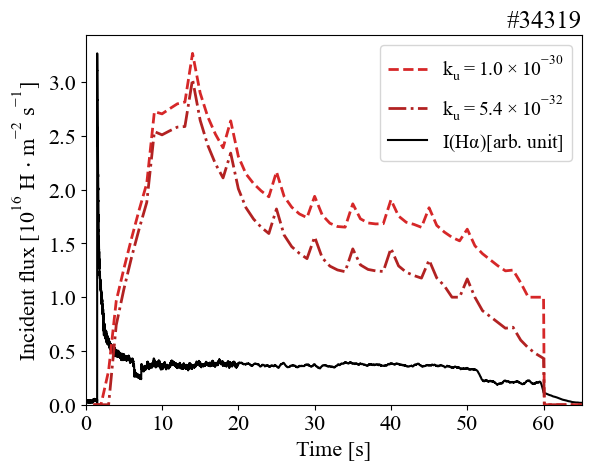

In [7]:
fig, ax1 = plt.subplots()

ax1.plot(xx_inc_opt_ku_first, inc_opt_ku_first/inc_order, '--', color='tab:red', zorder=5, linewidth=2,
         label=rf'$k_u = {ku_mantissa_first:.1f} \times 10^{{{ku_exponent_first}}}$') 

ax1.plot(xx_inc_opt_ku_second, inc_opt_ku_second/inc_order, '-.', color = "#b22222", zorder=5, linewidth=2,
         label=rf'$k_u = {ku_mantissa_second:.1f} \times 10^{{{ku_exponent_second}}}$') 

ax1.plot(xx_ha, yy_ha_clear, '-', color='black', zorder=1, label=r'I(H$\alpha$)[arb. unit]')

ax1.tick_params(labelsize=16)
ax1.set_xlabel("Time [s]", fontsize=16)
ax1.set_ylabel(rf'Incident flux [$10^{{{inc_exponent}}}$ H $\cdot$ m$^{{-2}}$ s$^{{-1}}$]', fontsize=16)
ax1.legend(fontsize=14)

ax1.text(1, 1.07, f"#{shot}",
    transform=ax1.transAxes, fontsize=18,
    ha="right", va="top")

ax1.set_xlim(left=0, right= shot_end+5)
ax1.set_ylim(bottom=0)

plt.show()

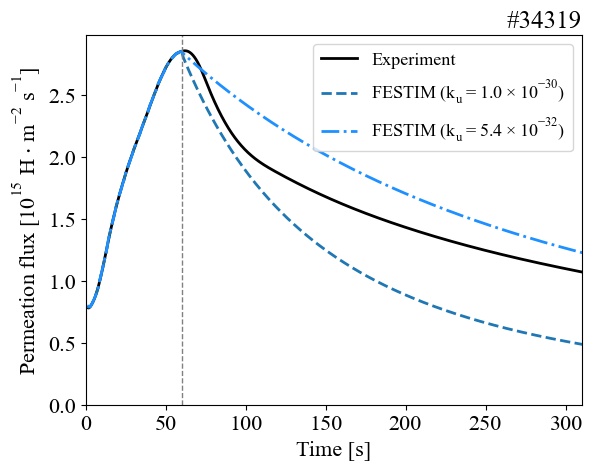

In [8]:
fig, ax1 = plt.subplots()

ax1.plot(xx_exp, yy_exp/exp_order, '-', label="Experiment", color='black', markersize=2, linewidth=2) 
ax1.plot(xx_opt_ku_first, perm_opt_ku_first/exp_order, '--', label=rf"FESTIM ($k_u = {ku_mantissa_first:.1f} \times 10^{{{ku_exponent_first}}}$)", color='tab:blue', linewidth=2)
ax1.plot(xx_opt_ku_second, perm_opt_ku_second/exp_order, '-.', label=rf"FESTIM ($k_u = {ku_mantissa_second:.1f} \times 10^{{{ku_exponent_second}}}$)", color='dodgerblue', linewidth=2)
ax1.tick_params(labelsize=16)
ax1.set_ylabel(rf'Permeation flux [$10^{{{exp_exponent}}}$ H $\cdot$ m$^{{-2}}$ s$^{{-1}}$]', fontsize=16)
ax1.set_xlabel("Time [s]", fontsize=16)
ax1.legend(fontsize=13)

ax1.text(1, 1.07, f"#{shot}",
    transform=ax1.transAxes, fontsize=18,
    ha="right", va="top")


ax1.set_xlim(left=0, right=shot_end+250)
ax1.set_ylim(bottom=0)

plt.axvline(x=shot_end, color='gray', linestyle='--', linewidth=1)

plt.show()